In [17]:
from langgraph.graph import StateGraph, START , END
from typing_extensions import TypedDict , Literal
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langchain_community.chat_models import ChatOllama


In [21]:
model = ChatOllama(model='llama3.1:latest')

model

ChatOllama(model='llama3.1:latest', output_version=None)

In [22]:
model.invoke("Hi my name is Manan Sood, what is your name?")

AIMessage(content="Nice to meet you, Manan! I don't have a personal name, but I'm an AI designed to assist and communicate with users in a helpful way. You can think of me as a conversational interface or a chatbot. I'm here to answer any questions, provide information, or just chat with you about various topics. How's your day going so far?", additional_kwargs={}, response_metadata={'model': 'llama3.1:latest', 'created_at': '2026-04-18T17:43:15.424369Z', 'message': {'role': 'assistant', 'content': ''}, 'done': True, 'done_reason': 'stop', 'total_duration': 7398989300, 'load_duration': 3137033200, 'prompt_eval_count': 24, 'prompt_eval_duration': 186678000, 'eval_count': 77, 'eval_duration': 3990647400}, id='lc_run--019da1b0-6815-7720-b364-5d34dbf86006-0', tool_calls=[], invalid_tool_calls=[])

In [23]:
class perisitance_demo(TypedDict):
    topic: str
    joke: str
    explanation: str


In [28]:
def get_joke(state: perisitance_demo):
    joke =  model.invoke(f"Tell me a joke about {state['topic']}")
    return {'joke': joke.content}

def get_explanation(state: perisitance_demo):
    explanation = model.invoke(f"Explain the joke: {state['joke']}")
    return {'explanation': explanation.content}



In [29]:
graph= StateGraph(perisitance_demo)

graph.add_node('get_joke', get_joke)
graph.add_node('get_explanation', get_explanation)

graph.add_edge(START, 'get_joke')
graph.add_edge('get_joke', 'get_explanation')
graph.add_edge('get_explanation', END)

checkpoint = InMemorySaver()

graph = graph.compile(checkpointer = checkpoint)

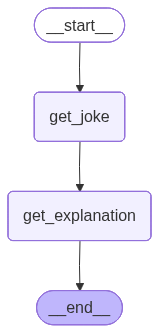

In [30]:
graph

In [31]:
config = {"configurable": {'thread_id': "1"}}
graph.invoke({'topic': 'programming'}, config = config)


{'topic': 'programming',
 'joke': 'Here\'s one:\n\nWhy do programmers prefer dark mode?\n\nBecause light attracts bugs.\n\n(Sorry, it\'s a bit of a "buggy" pun, but I hope it compiled to something funny for you!)',
 'explanation': 'A programmer\'s joke!\n\nThe punchline is a play on words. In two different contexts:\n\n1. **Light attracts bugs**: This refers to the fact that light can attract insects, like mosquitoes or flies.\n2. **Bugs in code**: In programming, "bugs" are errors or glitches in the software.\n\nSo, the joke says programmers prefer dark mode (a dark color scheme on a screen) because light (in this case, literally referring to light from the sun or lamps) attracts bugs (insects), but also because it\'s a clever way of saying that light-themed interfaces can attract "bugs" in code, i.e., errors and issues.\n\nThe final line, "it compiled to something funny for you," is another programmer joke, referencing the process of compiling source code into executable code. It\'s 

In [34]:
list(graph.get_state_history((config)))

[StateSnapshot(values={'topic': 'programming', 'joke': 'Here\'s one:\n\nWhy do programmers prefer dark mode?\n\nBecause light attracts bugs.\n\n(Sorry, it\'s a bit of a "buggy" pun, but I hope it compiled to something funny for you!)', 'explanation': 'A programmer\'s joke!\n\nThe punchline is a play on words. In two different contexts:\n\n1. **Light attracts bugs**: This refers to the fact that light can attract insects, like mosquitoes or flies.\n2. **Bugs in code**: In programming, "bugs" are errors or glitches in the software.\n\nSo, the joke says programmers prefer dark mode (a dark color scheme on a screen) because light (in this case, literally referring to light from the sun or lamps) attracts bugs (insects), but also because it\'s a clever way of saying that light-themed interfaces can attract "bugs" in code, i.e., errors and issues.\n\nThe final line, "it compiled to something funny for you," is another programmer joke, referencing the process of compiling source code into exe

In [35]:
graph.get_state(config=config)

StateSnapshot(values={'topic': 'programming', 'joke': 'Here\'s one:\n\nWhy do programmers prefer dark mode?\n\nBecause light attracts bugs.\n\n(Sorry, it\'s a bit of a "buggy" pun, but I hope it compiled to something funny for you!)', 'explanation': 'A programmer\'s joke!\n\nThe punchline is a play on words. In two different contexts:\n\n1. **Light attracts bugs**: This refers to the fact that light can attract insects, like mosquitoes or flies.\n2. **Bugs in code**: In programming, "bugs" are errors or glitches in the software.\n\nSo, the joke says programmers prefer dark mode (a dark color scheme on a screen) because light (in this case, literally referring to light from the sun or lamps) attracts bugs (insects), but also because it\'s a clever way of saying that light-themed interfaces can attract "bugs" in code, i.e., errors and issues.\n\nThe final line, "it compiled to something funny for you," is another programmer joke, referencing the process of compiling source code into exec